In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [7]:
tot_time =463
tlist = np.linspace(0, tot_time, tot_time)


qubit_level = 25
osc_level = 50


In [2]:

list_of_systems = []
list_of_kwargs = []

for kappa in [1e-3,1e-2]:
    for i, levels in zip([0,1,2],[30,30,50]):
        system = fluxonium_oscillator_system(
            EJ = 2.65,
            EC = 0.6,
            EL = 0.13,
            Er = 6.81289062,
            g_strength = 0.23,
            qubit_level = qubit_level,
            osc_level = osc_level,
            kappa = kappa,
            products_to_keep=[[ql, ol] for ql in [i] for ol in range(levels) ],
            computaional_states = '0,1',
            )

        kwargs = {'intial_state': system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])),
                    'tlist': tlist,
                    'osc_decay' : True,
                    'e_ops' : [system.a_trunc,system.a_trunc.dag()*system.a_trunc],
                    'amp' : 0.004,
                    't_stop':None,}
        
        list_of_systems.append(system)
        list_of_kwargs.append(kwargs)

results = run_fluxonium_osc_system_mesolve_jobs(list_of_systems,list_of_kwargs)

 *********73%*****      ] Elapsed 279.33s / Remaining 00:00:01:43          0%           ] Elapsed 0.00s / Remaining 00:00:00:00  [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.47s / Remaining 00:00:00:00[          0%           ] Elapsed 0.45s / Remaining 00:00:00:00[          0%           ] Elapsed 0.52s / Remaining 00:00:00:00[          0%           ] Elapsed 0.51s / Remaining 00:00:00:00[          0%           ] Elapsed 0.91s / Remaining 00:00:00:00[          0%           ] Elapsed 1.34s / Remaining 00:00:00:00[          0%           ] Elapsed 1.58s / Remaining 00:00:00:00[          0%           ] Elapsed 1.66s / Remaining 00:00:00:00[          1%           ] Elapsed 1.69s / Remaining 00:00:02:47[          1%           ] Elapsed 2.23s / Remaining 00:00:03:40[          0%           ] Elapsed 2.40s / Remaining

In [3]:
# import pickle
# with open('../pickles/mesolve_01.pkl', 'wb') as file:
#     pickle.dump(results, file)


In [3]:
with open('../pickles/mesolve_01.pkl', 'rb') as file:
    results = pickle.load(file)

In [4]:
detection_results_1em3 = [results[0],results[1],results[2]]
detection_results_1em2 = [results[3],results[4],results[5]]

0.1681026640978873


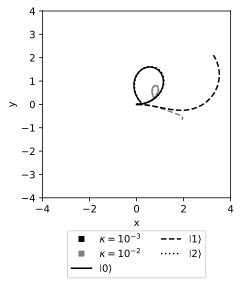

In [5]:

first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)
print(first_dominant_freq)


plt.figure(figsize=(3+3/8,3+3/8))

black_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='black', linestyle='-')
gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='gray', linestyle='-')


solid_line, = plt.plot([], [], color='black', linestyle='-')
dashed_line, = plt.plot([], [], color='black', linestyle='--')
dot_line, = plt.plot([], [], color='black', linestyle=':')

legend_lines = (black_line, gray_line, 
                solid_line,dashed_line,dot_line)
legend_labels = (r'$\kappa=10^{-3}$', r'$\kappa=10^{-2}$', 
                 rf'$\left|{0}\right>$',rf'$\left|{1}\right>$',rf'$\left|{2}\right>$')



# different settings have different color
for list_of_results,kappa,color in reversed(list(zip([detection_results_1em3,detection_results_1em2],
                                                     [r"10^{-3}",r"10^{-2}"],
                                                     ['black','gray']))):
    # different initial states has different line shape
    for i, linestype in zip([0,1,2],['-',':','--']):
        alpha = list_of_results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        line, = plt.plot(-alpha.imag,alpha.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)




plt.xlim(-4,4)
plt.ylim(-4,4)

plt.legend(legend_lines, legend_labels,
            loc='upper center', 
            bbox_to_anchor=(0.5, -0.15), 
            ncol=2)
# plt.axis('equal')
# plt.savefig("fig05_alpha.pdf", format='pdf', bbox_inches='tight')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    if dressed_state.dims[-1][0] == 1:
        dressed_state = qutip.ket2dm(dressed_state)
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)

nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0007539575827052492
trace: 0.9999999999993049
nonhermicity: Frobenius norm of the difference between rho and rho dag 5.558165491413523e-07
trace: 1.000000000000176
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.008739834496901662
trace: 0.9999999999997652


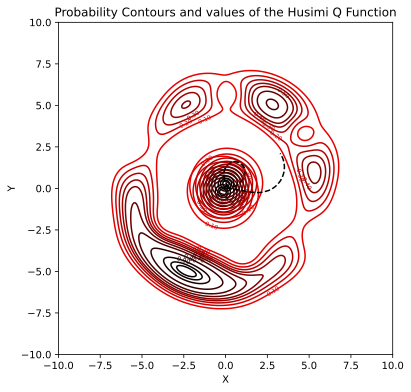

In [7]:
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [2] for ol in range(levels) ],
    computaional_states = '0,1',
    )

plt.figure(figsize=(6,6))
    
t_idx = tot_time-1
val = 0
for i in [0,1,2]:
    alpha_list = detection_results_1em3[i].expect[-2]
    alpha_rot_list = alpha_list * np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    line, = plt.plot(-alpha_rot_list.imag,alpha_rot_list.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)

    # alpha_rot_list_reverse = alpha_list * np.exp(1j * 2 * np.pi * first_dominant_freq * tlist)
    val = plot_husimi_probability_contours(dressed_state=detection_results_1em3[i].states[t_idx],
                                    product_to_dressed=system.product_to_dressed,
                                    qubit_level = qubit_level,
                                    osc_level = osc_level,
                                    )


plt.title("Probability Contours and values of the Husimi Q Function")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-10,10)
plt.ylim(-10,10)

plt.show()

In [10]:
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [2] for ol in range(10) ],
    computaional_states = '0,1',
    )
interactive_heatmap(results[1], system.product_to_dressed, qubit_level, osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=462), Output(…

 /tmp/ipykernel_9554/3134273684.py: 20

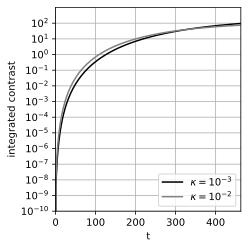

In [9]:
plt.figure(figsize=(3+3/8,3+3/8))

for list_of_results,kappa,kappa_val,color in zip([detection_results_1em3,detection_results_1em2],
                                                     ["10^{-3}",r"10^{-2}"],
                                                [1e-3,1e-2],
                                                ['black','gray']):
    alpha0 = list_of_results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha1 = list_of_results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                         )
        
    plt.plot(tlist,integrals,label=rf'$\kappa={kappa}$',color=color)

plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()

